In [ ]:
"""
Notebook 05 - Convergence Animation (Final)
============================================
Uses DeepFluoroDataset exactly like notebook 03.
Loads pose_history.npy saved during registration
to animate the REAL optimizer trajectory.
"""

In [1]:
# ── Cell 1: Imports ───────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.gridspec import GridSpec
import json
from pathlib import Path
from diffdrr.drr import DRR
from diffdrr.pose import RigidTransform
from diffdrrdata.deepfluoro import DeepFluoroDataset, Transforms
import warnings
warnings.filterwarnings("ignore")
device = torch.device("cpu")
print("Imports OK")

Imports OK


In [8]:
# ── Cell 2: Load config and setup (mirrors notebook 03) ──────────────────────
BASE = Path("/Users/zoecrookshank/Desktop/MEng - UofT/JEB1433")
with open(BASE / "outputs/dataset_config.json") as f:
    cfg = json.load(f)
SUBJECT_ID = cfg["subject_id"]
SUBSAMPLE  = cfg["subsample"]
deepfluoro = DeepFluoroDataset(id_number=SUBJECT_ID)
transform  = Transforms(deepfluoro.height // SUBSAMPLE)
drr = DRR(
    deepfluoro.subject,
    sdd    = deepfluoro.focal_len,
    height = deepfluoro.height // SUBSAMPLE,
    delx   = deepfluoro.delx * SUBSAMPLE,
    x0     = deepfluoro.x0,
    y0     = deepfluoro.y0,
).to(device)
print(f"Subject {SUBJECT_ID}, subsample {SUBSAMPLE}")
print(f"DRR renderer ready — {deepfluoro.height // SUBSAMPLE}px")

Subject 1, subsample 4
DRR renderer ready — 359px


In [9]:
# # ── Cell 3: Load pose history from notebook 03 ────────────────────────────────
# FRAME_IDX    = 0
# pose_history = np.load(BASE / "/Users/zoecrookshank/Desktop/MEng - UofT/JEB1433/outputs/registration_history.npy")   # (N, 4, 4)
# print(f"Pose history: {pose_history.shape[0]} frames")
# gt_img, gt_pose = deepfluoro[FRAME_IDX]
# gt_pose_dev     = gt_pose.to(device)
# # Reconstruct init pose (first saved pose)
# init_mat  = torch.tensor(pose_history[0], dtype=torch.float32).unsqueeze(0)
# init_pose = RigidTransform(init_mat).to(device)
# print(f"GT   translation: {gt_pose.matrix[0, :3, 3].numpy().round(2)} mm")
# print(f"Init translation: {init_mat[0, :3, 3].numpy().round(2)} mm")
FRAME_IDX    = 0
pose_history = np.load(BASE / "outputs/pose_history.npy", allow_pickle=True)
print(f"Pose history: {pose_history.shape[0]} frames")

gt_img, gt_pose = deepfluoro[FRAME_IDX]
gt_pose_dev     = gt_pose.to(device)

init_mat  = torch.tensor(pose_history[0], dtype=torch.float32).unsqueeze(0)
init_pose = RigidTransform(init_mat).to(device)

print(f"GT   translation: {gt_pose.matrix[0, :3, 3].numpy().round(2)} mm")
print(f"Init translation: {init_mat[0, :3, 3].numpy().round(2)} mm")

Pose history: 200 frames
GT   translation: [   6.95 -744.3    14.22] mm
Init translation: [  -6.81 -803.46   -1.53] mm


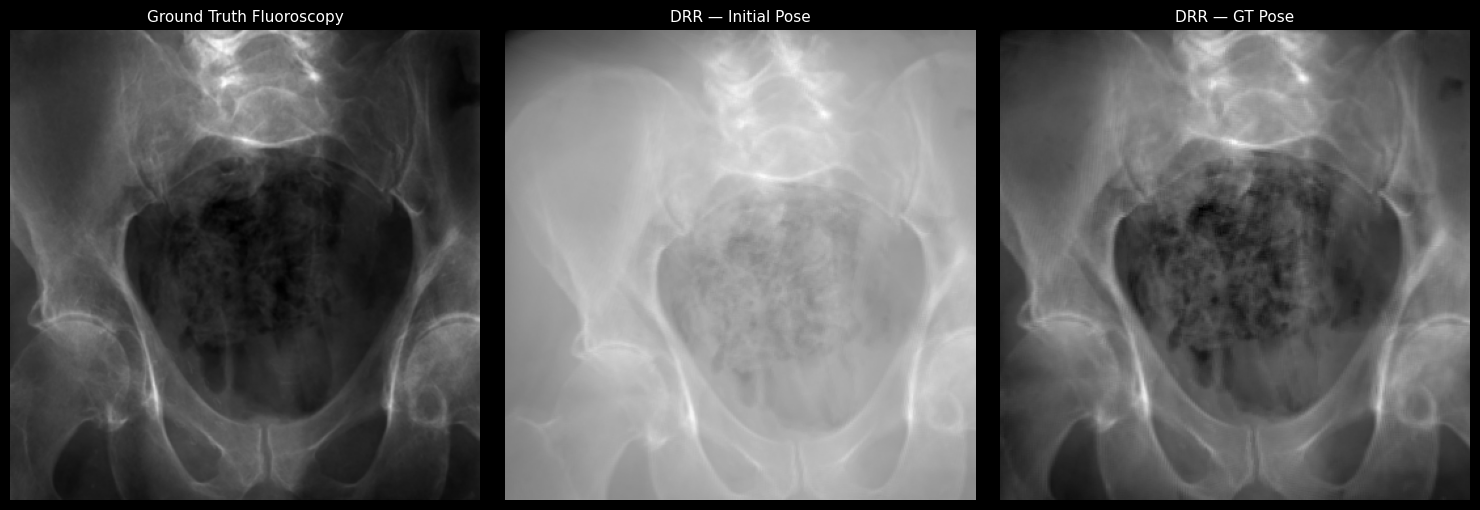

Saved anim_check.png — verify all 3 look correct before continuing


In [4]:
# ── Cell 4: Render key frames ─────────────────────────────────────────────────
with torch.no_grad():
    gt_img_t  = transform(gt_img)
    drr_gt    = transform(drr(gt_pose_dev).cpu())
    drr_init  = transform(drr(init_pose).cpu())
fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor="black")
for ax in axes:
    ax.set_facecolor("black")
    ax.axis("off")
axes[0].imshow(gt_img_t.squeeze().numpy(),  cmap="gray")
axes[0].set_title("Ground Truth Fluoroscopy", color="white", fontsize=11)
axes[1].imshow(drr_init.squeeze().numpy(),   cmap="gray")
axes[1].set_title("DRR — Initial Pose",      color="white", fontsize=11)
axes[2].imshow(drr_gt.squeeze().numpy(),     cmap="gray")
axes[2].set_title("DRR — GT Pose",           color="white", fontsize=11)
plt.tight_layout()
plt.savefig(BASE / "outputs/anim_check.png", dpi=120,
            bbox_inches="tight", facecolor="black")
plt.show()
print("Saved anim_check.png — verify all 3 look correct before continuing")

In [5]:
# ── Cell 5: Subsample trajectory for animation ────────────────────────────────
# Render every Nth pose to keep GIF size manageable
STEP = 4   # render every 4th saved pose → ~50 frames from 200
idxs = list(range(0, len(pose_history), STEP))
if idxs[-1] != len(pose_history) - 1:
    idxs.append(len(pose_history) - 1)   # always include last frame
print(f"Rendering {len(idxs)} frames from {len(pose_history)} saved poses...")
frames   = []
ncc_vals = []
ncc_fn   = torch.nn.CosineSimilarity(dim=0)   # simple proxy
target_t = transform(gt_img).to(device)
for n, idx in enumerate(idxs):
    mat  = torch.tensor(pose_history[idx], dtype=torch.float32).unsqueeze(0)
    pose = RigidTransform(mat).to(device)
    with torch.no_grad():
        rendered = transform(drr(pose).cpu())
    frames.append(rendered.squeeze().numpy())

    # Compute NCC between rendered and GT
    a = rendered.squeeze().flatten()
    b = target_t.squeeze().flatten().cpu()
    ncc = float((a * b).sum() / (a.norm() * b.norm() + 1e-8))
    ncc_vals.append(ncc)

    if (n + 1) % 10 == 0:
        print(f"  {n+1}/{len(idxs)} frames")
print(f"Done! NCC range: {min(ncc_vals):.3f} → {max(ncc_vals):.3f}")

Rendering 51 frames from 200 saved poses...
  10/51 frames
  20/51 frames
  30/51 frames
  40/51 frames
  50/51 frames
Done! NCC range: -0.275 → -0.116


In [11]:
# ── Cell 5: Subsample trajectory and render frames ────────────────────────────
STEP = 4
idxs = list(range(0, len(pose_history), STEP))
if idxs[-1] != len(pose_history) - 1:
    idxs.append(len(pose_history) - 1)

from skimage.transform import resize
def render_frame(pose_mat_np):
    mat  = torch.tensor(pose_mat_np, dtype=torch.float32).unsqueeze(0)
    pose = RigidTransform(mat).to(device)
    with torch.no_grad():
        img = drr(pose).cpu().squeeze().numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return img

# Normalise GT for display and resize to match DRR output
gt_raw     = gt_img.squeeze().numpy()
gt_raw     = (gt_raw - gt_raw.min()) / (gt_raw.max() - gt_raw.min() + 1e-8)

# Get DRR output size from a test render
test_frame = render_frame(pose_history[0])
drr_h, drr_w = test_frame.shape

gt_display = resize(gt_raw, (drr_h, drr_w), anti_aliasing=True)
print(f"GT resized: {gt_raw.shape} → {gt_display.shape}")
print(f"DRR size:   {drr_h} x {drr_w}")

print(f"Rendering {len(idxs)} frames...")
frames   = []
ncc_vals = []

for n, idx in enumerate(idxs):
    img = render_frame(pose_history[idx])
    frames.append(img)
    a   = img.flatten()
    b   = gt_display.flatten()
    ncc = float((a * b).sum() / (np.sqrt((a**2).sum() * (b**2).sum()) + 1e-8))
    ncc_vals.append(ncc)
    if (n + 1) % 10 == 0:
        print(f"  {n+1}/{len(idxs)} frames")

print(f"Done! NCC range: {min(ncc_vals):.3f} → {max(ncc_vals):.3f}")

GT resized: (1436, 1436) → (359, 359)
DRR size:   359 x 359
Rendering 51 frames...
  10/51 frames
  20/51 frames
  30/51 frames
  40/51 frames
  50/51 frames
Done! NCC range: 0.896 → 0.917


NameError: name 'ncc_line' is not defined

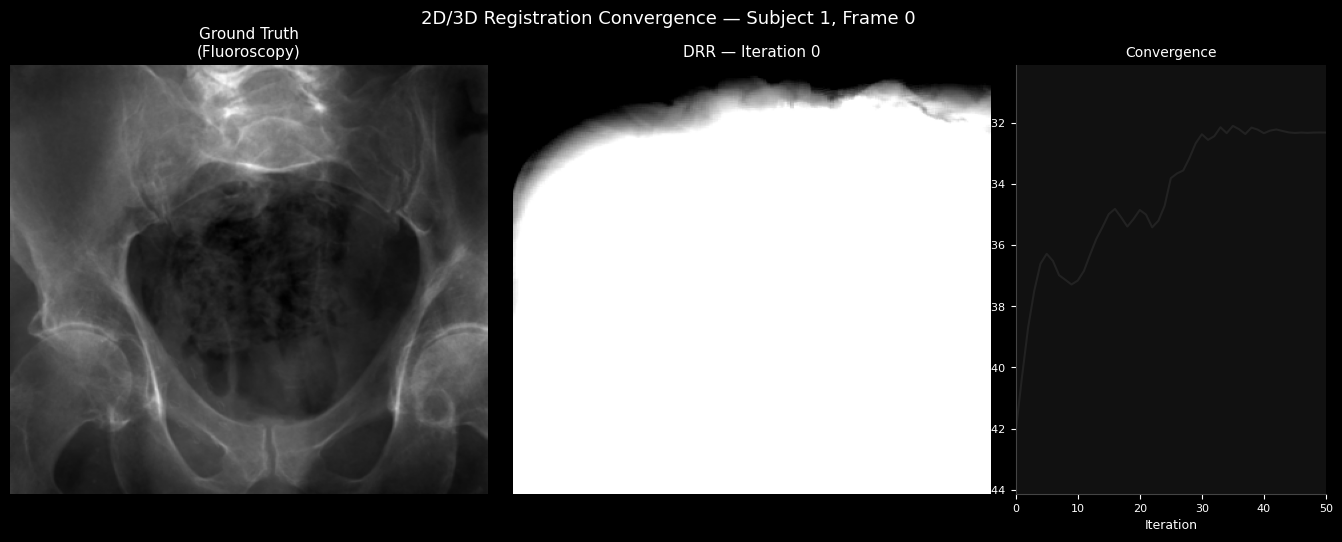

In [6]:
# ── Cell 6: Build animation ───────────────────────────────────────────────────
OUT_DIR = BASE / "outputs"
fig = plt.figure(figsize=(14, 5.5), facecolor="black")
gs  = GridSpec(1, 3, figure=fig, width_ratios=[2, 2, 1.3],
               wspace=0.06, left=0.03, right=0.97, top=0.88, bottom=0.1)
ax_gt  = fig.add_subplot(gs[0])
ax_drr = fig.add_subplot(gs[1])
ax_ncc = fig.add_subplot(gs[2])
for ax in [ax_gt, ax_drr]:
    ax.set_facecolor("black")
    ax.axis("off")
# NCC plot styling
ax_ncc.set_facecolor("#111")
for spine in ["top", "right"]:
    ax_ncc.spines[spine].set_visible(False)
for spine in ["bottom", "left"]:
    ax_ncc.spines[spine].set_color("#444")
ax_ncc.tick_params(colors="white", labelsize=8)
ax_ncc.set_xlabel("Iteration", color="white", fontsize=9)
ax_ncc.set_ylabel("NCC Similarity", color="white", fontsize=9)
ax_ncc.set_title("Convergence", color="white", fontsize=10, pad=6)
ax_ncc.set_xlim(0, len(ncc_vals) - 1)
ax_ncc.set_ylim(min(ncc_vals) - 0.02, max(ncc_vals) + 0.02)
ax_ncc.plot(ncc_vals, color="#333", linewidth=1.5, alpha=0.5)  # ghost curve
# Static GT panel
ax_gt.imshow(gt_img_t.squeeze().numpy(), cmap="gray", aspect="auto")
ax_gt.set_title("Ground Truth\n(Fluoroscopy)", color="white", fontsize=11, pad=6)
# Animated DRR panel
im_drr    = ax_drr.imshow(frames[0], cmap="gray", vmin=0, vmax=1, aspect="auto")
title_drr = ax_drr.set_title("DRR — Iteration 0", color="white", fontsize=11, pad=6)
# Animated DRR panel
im_drr    = ax_drr.imshow(frames[0], cmap="gray", vmin=0, vmax=1, aspect="auto")
title_drr = ax_drr.set_title("DRR — Iteration 0", color="white", fontsize=11, pad=6)
fig.suptitle(f"2D/3D Registration Convergence — Subject {SUBJECT_ID}, Frame {FRAME_IDX}",
             color="white", fontsize=13, y=0.98)
def update(i):
    im_drr.set_data(frames[i])
    real_iter = idxs[i]
    title_drr.set_text(f"DRR — Iteration {real_iter}")
    ncc_line.set_data(range(i + 1), ncc_vals[:i + 1])
    ncc_dot.set_data([i], [ncc_vals[i]])
    return [im_drr, title_drr, ncc_line, ncc_dot]
ani = animation.FuncAnimation(fig, update, frames=len(frames),
                               interval=120, blit=True)
gif_path = OUT_DIR / "convergence_animation.gif"
print("Saving GIF...")
ani.save(gif_path, writer="pillow", fps=10, dpi=120)
plt.close()
print(f"✅ Saved → {gif_path}")

In [7]:
##cell 6 V2
OUT_DIR = BASE / "outputs"

fig = plt.figure(figsize=(14, 5.5), facecolor="black")
gs  = GridSpec(1, 3, figure=fig, width_ratios=[2, 2, 1.3],
               wspace=0.06, left=0.03, right=0.97, top=0.88, bottom=0.1)

ax_gt  = fig.add_subplot(gs[0])
ax_drr = fig.add_subplot(gs[1])
ax_ncc = fig.add_subplot(gs[2])

for ax in [ax_gt, ax_drr]:
    ax.set_facecolor("black"); ax.axis("off")

ax_ncc.set_facecolor("#111")
for spine in ["top", "right"]: ax_ncc.spines[spine].set_visible(False)
for spine in ["bottom", "left"]: ax_ncc.spines[spine].set_color("#444")
ax_ncc.tick_params(colors="white", labelsize=8)
ax_ncc.set_xlabel("Iteration", color="white", fontsize=9)
ax_ncc.set_ylabel("NCC Similarity", color="white", fontsize=9)
ax_ncc.set_title("Convergence", color="white", fontsize=10, pad=6)
ax_ncc.set_xlim(0, len(ncc_vals) - 1)
ax_ncc.set_ylim(min(ncc_vals) - 0.02, max(ncc_vals) + 0.02)
ax_ncc.plot(ncc_vals, color="#333", linewidth=1.5, alpha=0.5)

ax_gt.imshow(gt_img_t.squeeze().numpy(), cmap="gray", aspect="auto")
ax_gt.set_title("Ground Truth\n(Fluoroscopy)", color="white", fontsize=11, pad=6)

im_drr    = ax_drr.imshow(frames[0], cmap="gray", vmin=0, vmax=1, aspect="auto")
title_drr = ax_drr.set_title("DRR — Iteration 0", color="white", fontsize=11, pad=6)

ncc_line, = ax_ncc.plot([], [], color="#00d4ff", linewidth=2)
ncc_dot,  = ax_ncc.plot([], [], "o", color="#ff6b6b", markersize=7, zorder=5)

fig.suptitle(f"2D/3D Registration Convergence — Subject {SUBJECT_ID}, Frame {FRAME_IDX}",
             color="white", fontsize=13, y=0.98)

def update(i):
    im_drr.set_data(frames[i])
    title_drr.set_text(f"DRR — Iteration {idxs[i]}")
    ncc_line.set_data(range(i + 1), ncc_vals[:i + 1])
    ncc_dot.set_data([i], [ncc_vals[i]])
    return [im_drr, title_drr, ncc_line, ncc_dot]

ani = animation.FuncAnimation(fig, update, frames=len(frames), interval=120, blit=True)

gif_path = OUT_DIR / "convergence_animation.gif"
print("Saving GIF...")
ani.save(gif_path, writer="pillow", fps=10, dpi=120)
plt.close()
print(f"✅ Saved → {gif_path}")

Saving GIF...
✅ Saved → /Users/zoecrookshank/Desktop/MEng - UofT/JEB1433/outputs/convergence_animation.gif


In [12]:
# ── Cell 6: Build and save animation V3─────────────────────────────────────────
OUT_DIR = BASE / "outputs"

fig = plt.figure(figsize=(14, 5.5), facecolor="black")
gs  = GridSpec(1, 3, figure=fig, width_ratios=[2, 2, 1.3],
               wspace=0.06, left=0.03, right=0.97, top=0.88, bottom=0.1)

ax_gt  = fig.add_subplot(gs[0])
ax_drr = fig.add_subplot(gs[1])
ax_ncc = fig.add_subplot(gs[2])

for ax in [ax_gt, ax_drr]:
    ax.set_facecolor("black"); ax.axis("off")

ax_ncc.set_facecolor("#111")
for spine in ["top", "right"]: ax_ncc.spines[spine].set_visible(False)
for spine in ["bottom", "left"]: ax_ncc.spines[spine].set_color("#444")
ax_ncc.tick_params(colors="white", labelsize=8)
ax_ncc.set_xlabel("Iteration", color="white", fontsize=9)
ax_ncc.set_ylabel("NCC Similarity", color="white", fontsize=9)
ax_ncc.set_title("Convergence", color="white", fontsize=10, pad=6)
ax_ncc.set_xlim(0, len(ncc_vals) - 1)
ax_ncc.set_ylim(min(ncc_vals) - 0.02, max(ncc_vals) + 0.02)
ax_ncc.plot(ncc_vals, color="#333", linewidth=1.5, alpha=0.5)

ax_gt.imshow(gt_display, cmap="gray", aspect="auto")
ax_gt.set_title("Ground Truth\n(Fluoroscopy)", color="white", fontsize=11, pad=6)

im_drr    = ax_drr.imshow(frames[0], cmap="gray", vmin=0, vmax=1, aspect="auto")
title_drr = ax_drr.set_title("DRR — Iteration 0", color="white", fontsize=11, pad=6)

ncc_line, = ax_ncc.plot([], [], color="#00d4ff", linewidth=2)
ncc_dot,  = ax_ncc.plot([], [], "o", color="#ff6b6b", markersize=7, zorder=5)

fig.suptitle(f"2D/3D Registration Convergence — Subject {SUBJECT_ID}, Frame {FRAME_IDX}",
             color="white", fontsize=13, y=0.98)

def update(i):
    im_drr.set_data(frames[i])
    title_drr.set_text(f"DRR — Iteration {idxs[i]}")
    ncc_line.set_data(range(i + 1), ncc_vals[:i + 1])
    ncc_dot.set_data([i], [ncc_vals[i]])
    return [im_drr, title_drr, ncc_line, ncc_dot]

ani = animation.FuncAnimation(fig, update, frames=len(frames), interval=120, blit=True)

gif_path = OUT_DIR / "convergence_animation_seeds.gif"
print("Saving GIF...")
ani.save(gif_path, writer="pillow", fps=10, dpi=120)
plt.close()
print(f"✅ Saved → {gif_path}")

Saving GIF...
✅ Saved → /Users/zoecrookshank/Desktop/MEng - UofT/JEB1433/outputs/convergence_animation_seeds.gif


In [ ]:
# ── Cell 7: Static 3-panel summary figure ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor="black")
for ax in axes:
    ax.set_facecolor("black")
    ax.axis("off")
axes[0].imshow(gt_img_t.squeeze().numpy(),  cmap="gray")
axes[0].set_title("Ground Truth\n(Fluoroscopy)",      color="white", fontsize=12, pad=8)
axes[1].imshow(frames[0],                             cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Initial DRR\n(Perturbed Pose)",    color="white", fontsize=12, pad=8)
axes[2].imshow(frames[-1],                            cmap="gray", vmin=0, vmax=1)
axes[2].set_title("Final DRR\n(Registered Pose)",     color="white", fontsize=12, pad=8)
fig.suptitle(f"2D/3D Registration — Subject {SUBJECT_ID}, Frame {FRAME_IDX}",
             color="white", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "comparison_panel.png", dpi=150,
            bbox_inches="tight", facecolor="black")
plt.show()
print("✅ Saved comparison_panel.png")
print("\nAll done! Output files:")
print(f"  {OUT_DIR}/convergence_animation.gif")
print(f"  {OUT_DIR}/comparison_panel.png")